# Chest X-Ray Pneumonia (Transfer Learning Experiment )
- ### Model Fine-Tuning Comparison
ResNet50과 DenseNet121의 Fine-Tuning 실험 결과를 비교하고, Validation 성능 및 Error Analysis를 바탕으로 최종 후보 모델을 선정한다.

선정된 최종 후보 모델에 대해 Test Dataset 평가를 수행하여 최종 성능을 확인한다.

In [1]:
## PC 전용(기본 경로)
import sys

sys.path.insert(0, r"D:\DEV\AI\src")
sys.path.insert(0, r"D:\DEV\AI\projects\chest-xray-pneumonia")

In [2]:
import sys
import importlib

# ============================================================
# Environment
# ============================================================ 
ENV = "pc"  

# ============================================================
# Project Configuration
# ============================================================

import cxp.cxp_config as cxp_config

importlib.reload(cxp_config)

config = cxp_config.configure_environment(ENV)


# ============================================================
# Python Path
# ============================================================

PROJECT_ROOT = config["PROJECT_ROOT"]
AILIB_ROOT = config["AILIB_ROOT"]

if str(AILIB_ROOT) not in sys.path:
    sys.path.insert(0, str(AILIB_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ============================================================
# Project Configuration
# ============================================================

DATA_ROOT = config["DATA_ROOT"]
PROCESSED_DATA_DIR = config["PROCESSED_DATA_DIR"]

TRAIN_DIR = config["TRAIN_DIR"]
VAL_DIR = config["VAL_DIR"]
TEST_DIR = config["TEST_DIR"]

IMAGE_INFO_CSV  = config["IMAGE_INFO_CSV"]

LOCAL_TRAIN_DIR = config["LOCAL_TRAIN_DIR"]
LOCAL_VAL_DIR = config["LOCAL_VAL_DIR"]
LOCAL_TEST_DIR = config["LOCAL_TEST_DIR"]

DATASET_TRAIN_DIR = config["DATASET_TRAIN_DIR"]
DATASET_VAL_DIR = config["DATASET_VAL_DIR"]
DATASET_TEST_DIR = config["DATASET_TEST_DIR"]

EXPERIMENTS_DIR = config["EXPERIMENTS_DIR"]
MODELS_DIR = config["MODELS_DIR"]
REPORTS_DIR = config["REPORTS_DIR"]

CLASS_TO_IDX = config["CLASS_TO_IDX"]
IDX_TO_CLASS = config["IDX_TO_CLASS"]


# ============================================================
# Environment Check
# ============================================================

print("=" * 60)
print("Environment Configuration")
print("=" * 60)

print(f"Environment     : {ENV}")
print(f"Project Root    : {PROJECT_ROOT}")
print(f"AI Library      : {AILIB_ROOT}")
print(f"Experiments Dir : {EXPERIMENTS_DIR}")
print(f"Reports Dir     : {REPORTS_DIR}")

print("=" * 60)

Environment Configuration
Environment     : pc
Project Root    : D:\DEV\AI\projects\chest-xray-pneumonia
AI Library      : D:\DEV\AI\src
Experiments Dir : D:\DEV\AI\projects\chest-xray-pneumonia\experiments
Reports Dir     : D:\DEV\AI\projects\chest-xray-pneumonia\reports


In [3]:
# ============================================================
# 2. Load Experiment Reports
# ============================================================

from pathlib import Path
import pandas as pd

# REPORTS_DIR = Path(REPORTS_DIR)

# metadata_path = REPORTS_DIR / "experiment_metadata.csv"
# history_path = REPORTS_DIR / "experiment_history.csv"

# experiment_summary = pd.read_csv(metadata_path)
# history_df = pd.read_csv(history_path)

# print("=" * 60)
# print("Loaded Experiment Reports")
# print("=" * 60)

# print(f"Metadata : {metadata_path}")
# print(f"History  : {history_path}")

# print()
# print(f"Summary shape : {experiment_summary.shape}")
# print(f"History shape : {history_df.shape}")

## 1. Experiment Objective

ResNet50과 DenseNet121의 Transfer Learning 및 Fine-Tuning 실험 결과를 비교하고, Frozen, Partial, Full Fine-Tuning 방식에 따른 Validation 성능과 오류 특성을 확인한다.

Learning Rate 실험을 통해 선정한 LR2 (1e-4)를 공통 조건으로 적용하여 모델 및 Fine-Tuning 방식에 따른 성능 차이를 비교한다.

Validation 결과를 종합하여 최종 후보 모델을 선정하고, 선정된 모델을 Test Dataset에 적용하여 최종 성능을 평가한다.

* Model: ResNet50 / DenseNet121
* Training Mode: Frozen / Partial / Full Fine-Tuning
* Optimizer: Adam
* Learning Rate: LR2 (1e-4)
* Epochs: 20
* Input Size: 512 × 512
* Normalization: ImageNet Mean / Std
* Loss: CrossEntropy<br>


## 2. Comparison Setup

각 모델의 Transfer Learning 및 Fine-Tuning 실험 결과를 동일한 Validation 조건에서 비교한다.

### Model Comparison

| Model       | Training Mode | Learning Rate | Epochs | Purpose     |
| ----------- | ------------- | ------------: | -----: | ----------- |
| ResNet50    | Frozen        |    LR2 (1e-4) |     20 | Baseline    |
| ResNet50    | Partial       |    LR2 (1e-4) |     20 | Fine-Tuning |
| ResNet50    | Full          |    LR2 (1e-4) |     20 | Fine-Tuning |
| DenseNet121 | Frozen        |    LR2 (1e-4) |     20 | Baseline    |
| DenseNet121 | Partial       |    LR2 (1e-4) |     20 | Fine-Tuning |
| DenseNet121 | Full          |    LR2 (1e-4) |     20 | Fine-Tuning |

### Comparison Metrics

Validation Dataset에서 다음 지표를 비교한다.

* Accuracy
* Precision
* Recall
* Specificity
* F1
* ROC-AUC
* False Positive (FP)
* False Negative (FN)

Confusion Matrix와 ROC / PR Curve를 함께 확인하여 모델별 오류 특성을 비교한다.

### Final Model Candidates

Validation 결과를 종합하여 최종 후보 모델을 선정한다.

최종 후보는 동일한 조건의 **Full Fine-Tuning 모델**을 중심으로 비교하며, 선정된 후보 모델은 Test Dataset에서 최종 평가를 수행한다.


## 3. Validation Result

각 Transfer Learning 및 Fine-Tuning 실험에서 수행한 Validation 결과를 비교한다.

### Validation Metrics

| Model       | Training Mode | Accuracy | Precision | Recall | Specificity |     F1 | ROC-AUC | FP | FN |
| ----------- | ------------- | -------: | --------: | -----: | ----------: | -----: | ------: | -: | -: |
| ResNet50    | Frozen        |   0.9368 |    0.9671 | 0.9472 |      0.9067 | 0.9570 |  0.9814 | 25 | 41 |
| ResNet50    | Partial       |   0.9847 |    0.9935 | 0.9858 |      0.9813 | 0.9897 |  0.9984 |  5 | 11 |
| ResNet50    | Full          |   0.9943 |    0.9961 | 0.9961 |      0.9888 | 0.9961 |  0.9998 |  3 |  3 |
| DenseNet121 | Frozen        |   0.9444 |    0.9724 | 0.9523 |      0.9216 | 0.9622 |  0.9858 | 21 | 37 |
| DenseNet121 | Partial       |   0.9904 |    0.9923 | 0.9948 |      0.9776 | 0.9936 |  0.9992 |  6 |  4 |
| DenseNet121 | Full          |   0.9904 |    0.9987 | 0.9884 |      0.9963 | 0.9935 |  0.9995 |  1 |  9 |

> **Note:** ResNet50 Frozen의 Validation 결과는 기존 Frozen Learning Rate 실험에서 LR2-EPOCH20 결과를 사용한다. 해당 값을 기존 Notebook의 Validation 결과에서 추가한다.


## 4. Metric Comparison

각 모델의 Validation 성능을 주요 평가 지표별로 비교한다.

Accuracy, Precision, Recall, Specificity, F1, ROC-AUC를 비교하여 모델별 성능 차이를 확인한다.

또한 False Positive (FP)와 False Negative (FN)을 함께 확인하여 단순한 평균 성능뿐 아니라 모델별 오류 특성의 차이를 확인한다.


In [4]:
validation_results_df = pd.DataFrame([
    {
        "model": "ResNet50",
        "training_mode": "Frozen",
        "experiment": "TL-RESNET50-LR",
        "run": "LR2-EPOCH20",
        "accuracy": 0.9368,
        "precision": 0.9671,
        "recall": 0.9472,
        "specificity": 0.9067,
        "f1": 0.9570,
        "roc_auc": 0.9814,
        "fp": 25,
        "fn": 41,
    },
    {
        "model": "ResNet50",
        "training_mode": "Partial",
        "experiment": "TL-RESNET50-PARTIAL",
        "run": "LR2-EPOCH20",
        "accuracy": 0.9847,
        "precision": 0.9935,
        "recall": 0.9858,
        "specificity": 0.9813,
        "f1": 0.9897,
        "roc_auc": 0.9984,
        "fp": 5,
        "fn": 11,
    },
    {
        "model": "ResNet50",
        "training_mode": "Full",
        "experiment": "TL-RESNET50-FULL",
        "run": "LR2-EPOCH20",
        "accuracy": 0.9943,
        "precision": 0.9961,
        "recall": 0.9961,
        "specificity": 0.9888,
        "f1": 0.9961,
        "roc_auc": 0.9998,
        "fp": 3,
        "fn": 3,
    },
    {
        "model": "DenseNet121",
        "training_mode": "Frozen",
        "experiment": "TL-DENSENET121-LR",
        "run": "LR2",
        "accuracy": 0.9444,
        "precision": 0.9724,
        "recall": 0.9523,
        "specificity": 0.9216,
        "f1": 0.9622,
        "roc_auc": 0.9858,
        "fp": 21,
        "fn": 37,
    },
    {
        "model": "DenseNet121",
        "training_mode": "Partial",
        "experiment": "TL-DENSENET121-PARTIAL",
        "run": "LR2",
        "accuracy": 0.9904,
        "precision": 0.9923,
        "recall": 0.9948,
        "specificity": 0.9776,
        "f1": 0.9936,
        "roc_auc": 0.9992,
        "fp": 6,
        "fn": 4,
    },
    {
        "model": "DenseNet121",
        "training_mode": "Full",
        "experiment": "TL-DENSENET121-FULL",
        "run": "LR2",
        "accuracy": 0.9904,
        "precision": 0.9987,
        "recall": 0.9884,
        "specificity": 0.9963,
        "f1": 0.9935,
        "roc_auc": 0.9995,
        "fp": 1,
        "fn": 9,
    },
])

validation_results_df

,model,training_mode,experiment,run,accuracy,precision,recall,specificity,f1,roc_auc,fp,fn
0,ResNet50,Frozen,TL-RESNET50-LR,LR2-EPOCH20,0.9368,0.9671,0.9472,0.9067,0.9570,0.9814,25,41
1,ResNet50,Partial,TL-RESNET50-PARTIAL,LR2-EPOCH20,0.9847,0.9935,0.9858,0.9813,0.9897,0.9984,5,11
2,ResNet50,Full,TL-RESNET50-FULL,LR2-EPOCH20,0.9943,0.9961,0.9961,0.9888,0.9961,0.9998,3,3
3,DenseNet121,Frozen,TL-DENSENET121-LR,LR2,0.9444,0.9724,0.9523,0.9216,0.9622,0.9858,21,37
4,DenseNet121,Partial,TL-DENSENET121-PARTIAL,LR2,0.9904,0.9923,0.9948,0.9776,0.9936,0.9992,6,4
5,DenseNet121,Full,TL-DENSENET121-FULL,LR2,0.9904,0.9987,0.9884,0.9963,0.9935,0.9995,1,9


### 4-1. Metric Comparison — 전체 지표 비교

In [7]:
import cxp.cxp_plot as cxp_plot

cxp_plot.plot_metric_comparison(
    validation_results_df,
    score_range=(0.8, 1.0),
)

### 4-2. 오류 개수 비교

In [10]:
cxp_plot.plot_metric_comparison(
    validation_results_df,
    metrics=["fp", "fn"],
    score_range=(0, 60),
)

## 5. Error Analysis


Validation Dataset에서 발생한 False Positive (FP)와 False Negative (FN)를 비교하여 모델별 오류 특성을 확인한다.

FP는 NORMAL 이미지를 PNEUMONIA로 예측한 경우이며, FN은 PNEUMONIA 이미지를 NORMAL로 예측한 경우이다.

각 Fine-Tuning 실험에서 확인한 오류 사례와 Grad-CAM 결과를 함께 검토하여 모델이 어떤 영역에 반응하는지 확인한다.

Grad-CAM은 모델의 예측에 영향을 준 영역을 시각화하는 도구이므로, 시각화 결과를 실제 병변 위치나 의학적 판단 근거로 해석하지 않는다.

### 5-1. ResNet50
 

ResNet50 Partial은 Validation set에서 FP 5건, FN 11건이 발생하였으며, Full은 FP 3건, FN 3건이 발생하였다.

Full Fine-Tuning에서 FP와 FN이 모두 감소하여 Partial 대비 오류 개수가 줄어든 것을 확인할 수 있다.

Grad-CAM 결과에서는 Fine-Tuning 방식에 따라 모델의 활성화 영역에 차이가 나타났으며, 일부 사례에서는 폐 실질 외부 영역에 대한 활성화도 확인되었다.

이는 모델이 영상의 핵심 병변 정보 외에 영상의 배경이나 촬영 특성 등의 영향을 받을 가능성을 확인하기 

### 5-2. DenseNet121 

DenseNet121 Partial은 Validation set에서 FP 6건, FN 4건이 발생하였으며, Full은 FP 1건, FN 9건이 발생하였다.

Full Fine-Tuning에서는 FP가 감소한 반면 FN이 증가하였다. 따라서 Fine-Tuning 방식에 따라 오류 유형에 차이가 나타나는 것을 확인할 수 있다.

Grad-CAM 결과에서는 일부 사례에서 폐 실질 외부 영역 및 영상의 가장자리 영역에 대한 활성화가 확인되었으며, 일부 FN 사례에서는 폐 내부 및 하부 흉부 영역에 활성화가 나타났음에도 PNEUMONIA로 분류하지 못하는 사례가 확인되었다.

Grad-CAM은 모델의 예측에 영향을 준 영역을 시각화하는 도구이므로 실제 병변 위치나 의학적 판단 근거로 해석하지 않았다.

## 6. Final Model Candidates


Validation 성능과 Error Analysis 결과를 바탕으로 Test Dataset 평가를 수행할 최종 후보 모델을 선정한다.

Frozen 모델은 Transfer Learning의 기준 성능을 확인하기 위한 Baseline으로 사용하였으며, 최종 후보에서는 제외한다.

최종 후보는 동일한 Learning Rate (LR2, 1e-4)와 20 Epoch 조건의 Full Fine-Tuning 모델로 구성한다.

| Model | Training Mode | Run | Accuracy | F1 | ROC-AUC | FP | FN |
|---|---|---|---:|---:|---:|---:|---:|
| ResNet50 | Full | LR2-EPOCH20 | 0.9943 | 0.9961 | 0.9998 | 3 | 3 |
| DenseNet121 | Full | LR2 | 0.9904 | 0.9935 | 0.9995 | 1 | 9 |

두 모델 모두 높은 Validation 성능을 보였으며, 오류 유형에서는 차이가 나타났다.

ResNet50 Full은 FP와 FN이 각각 3건으로 나타났으며, DenseNet121 Full은 FP 1건, FN 9건으로 나타났다.

따라서 두 모델을 최종 후보로 유지하고 동일한 Test Dataset에 적용하여 최종 성능을 확인한다.

[{'experiment': 'TL-RESNET50-FULL', 'run': 'LR2-EPOCH20'},
 {'experiment': 'TL-DENSENET121-FULL', 'run': 'LR2'}]

In [ ]:
# final_candidate_runs = [
#     data
#     for data in analysis_runs
#     if any(
#         data["experiment"] == candidate["experiment"]
#         and data["run"] == candidate["run"]
#         for candidate in final_candidates
#     )
# ]

# final_candidate_runs

## 7. Test Evaluation

Validation 결과를 바탕으로 선정한 최종 후보 모델을 Test Dataset에 적용하여 최종 성능을 평가한다.

Test Dataset은 모델 선정 과정에 사용하지 않고, 최종 후보 모델의 일반화 성능을 확인하는 목적으로 사용한다.

평가 지표는 Validation 단계와 동일하게 Accuracy, Precision, Recall, Specificity, F1, ROC-AUC, FP, FN을 사용한다.

In [17]:
# ============================================================
#  Load Experiment Reports
# ============================================================

from pathlib import Path
import pandas as pd

REPORTS_DIR = Path(REPORTS_DIR)

metadata_path = REPORTS_DIR / "experiment_metadata.csv"
history_path = REPORTS_DIR / "experiment_history.csv"

experiment_summary = pd.read_csv(metadata_path)
history_df = pd.read_csv(history_path)

print("=" * 60)
print("Loaded Experiment Reports")
print("=" * 60)

print(f"Metadata : {metadata_path}")
print(f"History  : {history_path}")

print()
print(f"Summary shape : {experiment_summary.shape}")
print(f"History shape : {history_df.shape}")

Loaded Experiment Reports
Metadata : D:\DEV\AI\projects\chest-xray-pneumonia\reports\experiment_metadata.csv
History  : D:\DEV\AI\projects\chest-xray-pneumonia\reports\experiment_history.csv

Summary shape : (14, 20)
History shape : (230, 8)


In [18]:
# ============================================================
# 3. Experiment List
# ============================================================

experiment_names = experiment_summary["experiment"].unique()

print("=" * 60)
print("Experiments")
print("=" * 60)

for i, name in enumerate(experiment_names, 1):

    runs = experiment_summary.loc[
        experiment_summary["experiment"] == name,
        "run"
    ].tolist()

    print(f"{i}. {name}")
    print(f"   Runs: {runs}")

Experiments
1. TL-DENSENET121-FULL
   Runs: ['LR1', 'LR2']
2. TL-DENSENET121-LR
   Runs: ['LR1', 'LR2']
3. TL-DENSENET121-PARTIAL
   Runs: ['LR1', 'LR2']
4. TL-RESNET50-FULL
   Runs: ['LR2', 'LR2-EPOCH20']
5. TL-RESNET50-LR
   Runs: ['LR1', 'LR2', 'LR2-EPOCH20', 'LR3']
6. TL-RESNET50-PARTIAL
   Runs: ['LR2', 'LR2-EPOCH20']


In [22]:
# ============================================================
# 7-1. Test DataFrame
# ============================================================

test_rows = []

test_proc_path = Path(DATASET_TEST_DIR) 

for class_dir in test_proc_path.iterdir():

    if not class_dir.is_dir():
        continue

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() != ".png":
            continue

        test_rows.append({
            "Folder": class_dir.name,
            "File": image_path.name,
        })


test_df = pd.DataFrame(test_rows)

print("=" * 60)
print("Test Dataset")
print("=" * 60)

print(f"Samples : {len(test_df)}")
print()

display(
    test_df.head()
)

print(
    test_df["Folder"].value_counts()
)

Test Dataset
Samples : 624



,Folder,File
0,NORMAL,IM-0001-0001.png
1,NORMAL,IM-0003-0001.png
2,NORMAL,IM-0005-0001.png
3,NORMAL,IM-0006-0001.png
4,NORMAL,IM-0007-0001.png


Folder
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


In [23]:
# ============================================================
# 7-2. Test Loader
# ============================================================

import json

# from ailib.data_split_v2 import split_train_validation
from ailib.transform_v2 import create_transform
from ailib.dataset_v2 import ImageDataset
from ailib.dataloader_v2 import create_dataloader


# ============================================================
# Batch Size : 실험환경에 따라 변경
# ============================================================

BATCH_SIZE = 32

# ============================================================
# Load Test Dataset Metadata
# ============================================================

# test_image_info = pd.read_csv(
#     IMAGE_INFO_CSV
# )

# test_df = test_image_info[
#     test_image_info["split"] == "test"
# ].copy()


# ============================================================
# Load Split Metadata
# ============================================================

split_config_path = REPORTS_DIR / "split_config.json"

if not split_config_path.exists():
    raise FileNotFoundError(
        f"Split metadata not found: {split_config_path}"
    )

with open(
    split_config_path,
    "r",
    encoding="utf-8",
) as f:
    split_config = json.load(f)
 
# ============================================================
# Preprocessing Configuration
# ============================================================

IMAGE_SIZE = split_config["preprocessing"]["image_size"]
NORMALIZATION = split_config["preprocessing"]["normalization"]


# ============================================================
# Test Transform
# ============================================================

eval_transform = create_transform(
    image_size=IMAGE_SIZE,
    mean=NORMALIZATION["mean"],
    std=NORMALIZATION["std"],
)


# ============================================================
# Test Dataset
# ============================================================

test_dataset = ImageDataset(
    dataframe=test_df,
    data_dir=DATASET_TEST_DIR,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform,
)


# ============================================================
# Test DataLoader
# ============================================================

test_loader = create_dataloader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ============================================================
# Result
# ============================================================

print("=" * 60)
print("Test Loader")
print("=" * 60)

print(f"Test        : {len(test_dataset)}")
print(f"Image Size  : {IMAGE_SIZE}")
print(f"Batch Size  : {BATCH_SIZE}")
print(f"Shuffle     : False")
print("=" * 60)

Test Loader
Test        : 624
Image Size  : 512
Batch Size  : 32
Shuffle     : False


In [25]:
# ============================================================
# 7-3. Final Candidate Runs
# ============================================================

final_candidates = [
    {
        "experiment": "TL-RESNET50-FULL",
        "run": "LR2-EPOCH20",
    },
    {
        "experiment": "TL-DENSENET121-FULL",
        "run": "LR2",
    },
]


final_candidate_runs = experiment_summary[
    experiment_summary.apply(
        lambda row: any(
            row["experiment"] == candidate["experiment"]
            and row["run"] == candidate["run"]
            for candidate in final_candidates
        ),
        axis=1,
    )
].copy()


display(
    final_candidate_runs[
        [
            "experiment",
            "run",
            "model",
            "channels",
            "learning_rate",
            "num_epochs",
            "best_epoch",
            "best_validation_accuracy",
        ]
    ].reset_index(drop=True)
)

,experiment,run,model,channels,learning_rate,num_epochs,best_epoch,best_validation_accuracy
0,TL-DENSENET121-FULL,LR2,DenseNet,3,0.0001,20,13,0.996169
1,TL-RESNET50-FULL,LR2-EPOCH20,ResNet,3,0.0001,20,7,0.993295


In [24]:
import importlib
import cxp.cxp_evaluation as cxp_evaluation

importlib.reload(cxp_evaluation)

<module 'cxp.cxp_evaluation' from 'D:\\DEV\\AI\\projects\\chest-xray-pneumonia\\cxp\\cxp_evaluation.py'>

In [44]:
# ============================================================
# 7-4. Model Load
# ============================================================

import torch

from cxp.cxp_model import (
    build_transfer_model,
    configure_fine_tuning,
)

from ailib.device import get_device
DEVICE = get_device()  

def load_experiment_model(run_info):

    experiment = run_info["experiment"]
    run = run_info["run"]

    model_path = (
        EXPERIMENTS_DIR
        / experiment
        / run
        / "model.pth"
    )

    print(model_path)

    # --------------------------------------------------------
    # Model Configuration
    # --------------------------------------------------------

    model_name = run_info["model"]
    channels = run_info["channels"]

    if model_name == "ResNet":
        model_name = "resnet50"
    else:        
        model_name = "densenet121" 

    print(model_name)
    # --------------------------------------------------------
    # Build Model
    # --------------------------------------------------------

    model = build_transfer_model(
        model_name=model_name,
        num_classes=2,
        in_channels=channels,
        pretrained=True,
    )

    # --------------------------------------------------------
    # Configure Model
    # --------------------------------------------------------

    model = configure_fine_tuning(
        model=model,
        model_name=model_name,
        fine_tuning_mode="full",
    )

    # --------------------------------------------------------
    # Load Checkpoint
    # --------------------------------------------------------

    checkpoint = torch.load(
        model_path,
        map_location=DEVICE,
    )

    model.load_state_dict(checkpoint)

    model = model.to(DEVICE)
    model.eval()

    return model

In [45]:
# ============================================================
# 7-4. Test Evaluation
# ============================================================

from cxp.cxp_evaluation import (
    predict,
    calculate_metrics,
)

test_results = []
test_predictions = {}

for _, run_info in final_candidate_runs.iterrows():

    experiment = run_info["experiment"]
    run = run_info["run"]

    print(
        f"Evaluating Test: {experiment} / {run}"
    )

    # --------------------------------------------------------
    # Load Model
    # --------------------------------------------------------

    model = load_experiment_model(
        run_info
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    labels, predictions, probabilities = predict(
        model=model,
        loader=test_loader,
        device=DEVICE,
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    metrics = calculate_metrics(
        labels=labels,
        predictions=predictions,
        probabilities=probabilities,
    )

    test_results.append({
        "experiment": experiment,
        "run": run,
        **metrics,
    })

    # --------------------------------------------------------
    # Store Predictions
    # --------------------------------------------------------

    test_predictions[(experiment, run)] = {
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
    }

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

Evaluating Test: TL-DENSENET121-FULL / LR2
D:\DEV\AI\projects\chest-xray-pneumonia\experiments\TL-DENSENET121-FULL\LR2\model.pth
densenet121
Evaluating Test: TL-RESNET50-FULL / LR2-EPOCH20
D:\DEV\AI\projects\chest-xray-pneumonia\experiments\TL-RESNET50-FULL\LR2-EPOCH20\model.pth
resnet50


In [37]:
test_results_df = pd.DataFrame(
    test_results
)

test_results_df

,experiment,run,accuracy,precision,recall,specificity,f1,roc_auc,tn,fp,fn,tp
0,TL-DENSENET121-FULL,LR2,0.812500,0.771372,0.994872,0.508547,0.868981,0.944554,119,115,2,388
1,TL-RESNET50-FULL,LR2-EPOCH20,0.759615,0.722222,1.000000,0.358974,0.838710,0.926633,84,150,0,390


## 8. Error Analysis

### 8-1. Test Confusion Matrix

TL-DENSENET121-FULL / LR2


,Pred NORMAL,Pred PNEUMONIA
Actual NORMAL,119,115
Actual PNEUMONIA,2,388


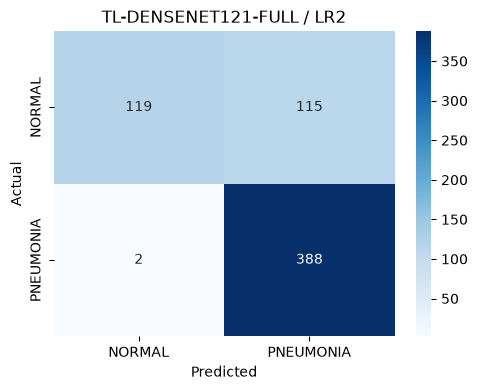

TL-RESNET50-FULL / LR2-EPOCH20


,Pred NORMAL,Pred PNEUMONIA
Actual NORMAL,84,150
Actual PNEUMONIA,0,390


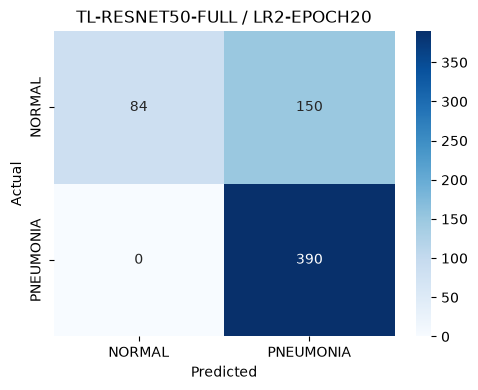

In [46]:
# ============================================================
# 8-1. Test Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for _, row in final_candidate_runs.iterrows():

    experiment = row["experiment"]
    run = row["run"]

    result = test_predictions[(experiment, run)]

    labels = result["labels"]
    predictions = result["predictions"]

    cm = confusion_matrix(
        labels,
        predictions,
    )

    print("=" * 60)
    print(f"{experiment} / {run}")
    print("=" * 60)

    display(
        pd.DataFrame(
            cm,
            index=["Actual NORMAL", "Actual PNEUMONIA"],
            columns=["Pred NORMAL", "Pred PNEUMONIA"],
        )
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["NORMAL", "PNEUMONIA"],
        yticklabels=["NORMAL", "PNEUMONIA"],
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{experiment} / {run}")

    plt.tight_layout()
    plt.show()

### 8-2. False Positive Analysis

In [ ]:
# ============================================================
# 8-2. False Positive Analysis
# ============================================================

import matplotlib.pyplot as plt

experiment = "TL-DENSENET121-FULL"
run = "LR2"

result = test_predictions[(experiment, run)]

labels = result["labels"]
predictions = result["predictions"]
probabilities = result["probabilities"]

fp_indices = [
    i
    for i, (label, prediction) in enumerate(
        zip(labels, predictions)
    )
    if label == 0 and prediction == 1
]

print("=" * 60)
print(f"{experiment} / {run}")
print("=" * 60)
print(f"False Positives : {len(fp_indices)}")

TL-DENSENET121-FULL / LR2
False Positives : 115


In [49]:
import numpy as np

labels = np.array(labels)
predictions = np.array(predictions)
probabilities = np.array(probabilities)

fp_df = test_df.iloc[fp_indices].copy()

fp_df["actual"] = labels[fp_indices]
fp_df["prediction"] = predictions[fp_indices]
fp_df["probability"] = probabilities[fp_indices]

display(fp_df.head(20))

,Folder,File,actual,prediction,probability
0,NORMAL,IM-0001-0001.png,0,1,0.983101
1,NORMAL,IM-0003-0001.png,0,1,0.829607
3,NORMAL,IM-0006-0001.png,0,1,0.865131
8,NORMAL,IM-0011-0001-0002.png,0,1,0.632969
11,NORMAL,IM-0015-0001.png,0,1,0.999565
14,NORMAL,IM-0019-0001.png,0,1,0.970973
16,NORMAL,IM-0022-0001.png,0,1,0.999999
17,NORMAL,IM-0023-0001.png,0,1,0.939298
22,NORMAL,IM-0030-0001.png,0,1,0.640931
32,NORMAL,IM-0043-0001.png,0,1,0.770369


In [ ]:
# ============================================================
# Visualize False Positives
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

# PNEUMONIA 확률이 높은 순으로 정렬
fp_df = (
    fp_df
    .sort_values("probability", ascending=False)
    .reset_index(drop=True)
)

display(fp_df.head(12))

,Folder,File,actual,prediction,probability
0,NORMAL,NORMAL2-IM-0198-0001.png,0,1,1.000000
1,NORMAL,NORMAL2-IM-0195-0001.png,0,1,1.000000
2,NORMAL,NORMAL2-IM-0201-0001.png,0,1,1.000000
3,NORMAL,NORMAL2-IM-0238-0001.png,0,1,1.000000
4,NORMAL,NORMAL2-IM-0246-0001.png,0,1,1.000000
5,NORMAL,NORMAL2-IM-0232-0001.png,0,1,1.000000
6,NORMAL,NORMAL2-IM-0210-0001.png,0,1,1.000000
7,NORMAL,NORMAL2-IM-0221-0001.png,0,1,1.000000
8,NORMAL,NORMAL2-IM-0237-0001.png,0,1,1.000000
9,NORMAL,NORMAL2-IM-0256-0001.png,0,1,1.000000


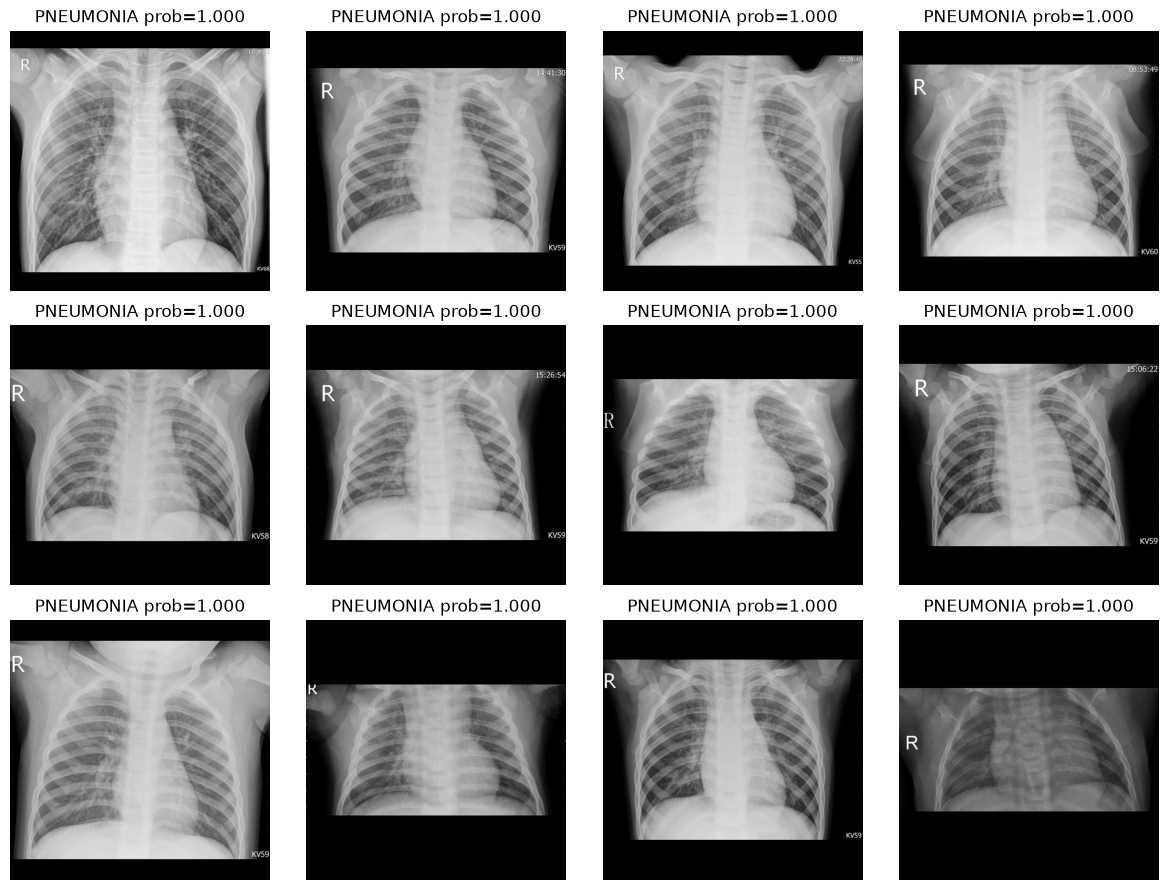

In [ ]:
# ============================================================
# False Positive Images
# ============================================================

sample_df = fp_df.head(12)

fig, axes = plt.subplots(
    3, 4,
    figsize=(12, 9),
)

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):

    image_path = (
        Path(DATASET_TEST_DIR)
        / row["Folder"]
        / row["File"]
    )

    image = Image.open(image_path).convert("L")

    ax.imshow(image, cmap="gray")

    ax.set_title(
        f"PNEUMONIA prob={row['probability']:.3f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FP Grad-CAM
# ============================================================

experiment = "TL-DENSENET121-FULL"
run = "LR2"

fp_samples = fp_df.head(6)

display(fp_samples)

,Folder,File,actual,prediction,probability
0,NORMAL,NORMAL2-IM-0198-0001.png,0,1,1.0
1,NORMAL,NORMAL2-IM-0195-0001.png,0,1,1.0
2,NORMAL,NORMAL2-IM-0201-0001.png,0,1,1.0
3,NORMAL,NORMAL2-IM-0238-0001.png,0,1,1.0
4,NORMAL,NORMAL2-IM-0246-0001.png,0,1,1.0
5,NORMAL,NORMAL2-IM-0232-0001.png,0,1,1.0


In [ ]:
# ============================================================
#  FP Grad-CAM
# ============================================================

experiment = "TL-DENSENET121-FULL"
run = "LR2"

run_info = final_candidate_runs[
    (final_candidate_runs["experiment"] == experiment)
    & (final_candidate_runs["run"] == run)
].iloc[0]

model = load_experiment_model(run_info)

fp_samples = fp_df.head(6)

display(fp_samples)

D:\DEV\AI\projects\chest-xray-pneumonia\experiments\TL-DENSENET121-FULL\LR2\model.pth
densenet121


,Folder,File,actual,prediction,probability
0,NORMAL,NORMAL2-IM-0198-0001.png,0,1,1.0
1,NORMAL,NORMAL2-IM-0195-0001.png,0,1,1.0
2,NORMAL,NORMAL2-IM-0201-0001.png,0,1,1.0
3,NORMAL,NORMAL2-IM-0238-0001.png,0,1,1.0
4,NORMAL,NORMAL2-IM-0246-0001.png,0,1,1.0
5,NORMAL,NORMAL2-IM-0232-0001.png,0,1,1.0


In [ ]:
eval_transform = create_transform(
    image_size=IMAGE_SIZE,
    mean=NORMALIZATION["mean"],
    std=NORMALIZATION["std"],
)

fp_gradcam = fp_df.copy()

fp_gradcam["y_true"] = fp_gradcam["actual"]
fp_gradcam["y_pred"] = fp_gradcam["prediction"]
fp_gradcam["y_prob"] = fp_gradcam["probability"]

D:\DEV\AI\projects\chest-xray-pneumonia\experiments\TL-DENSENET121-FULL\LR2\model.pth
densenet121


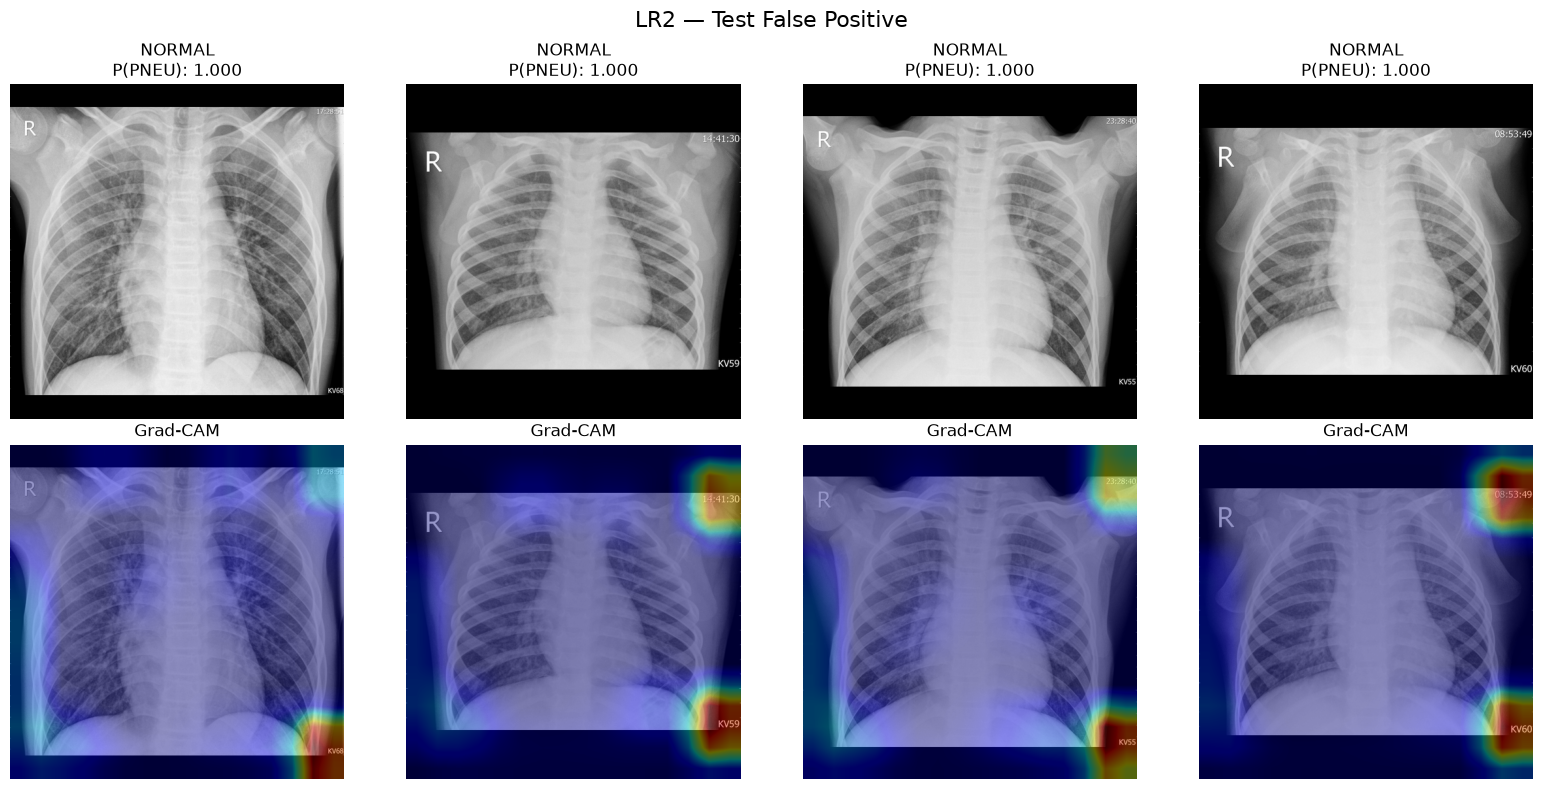

In [ ]:
# ============================================================
# Test FP Grad-CAM
# ============================================================

from cxp import cxp_gradcam

GRADCAM_EXPERIMENT = "TL-DENSENET121-FULL"
GRADCAM_RUN = "LR2"
N_SAMPLES = 4

run_info = final_candidate_runs[
    (final_candidate_runs["experiment"] == GRADCAM_EXPERIMENT)
    & (final_candidate_runs["run"] == GRADCAM_RUN)
].iloc[0]

model = load_experiment_model(run_info)

target_layer = cxp_gradcam.get_gradcam_target_layer(
    model=model,
    model_name=run_info["model"],
)

gradcam = cxp_gradcam.GradCAM(
    model=model,
    target_layer=target_layer,
)

eval_transform = create_transform(
    image_size=IMAGE_SIZE,
    mean=NORMALIZATION["mean"],
    std=NORMALIZATION["std"],
)

cxp_gradcam.plot_gradcam_samples(
    dataframe=fp_gradcam,
    gradcam=gradcam,
    transform=eval_transform,
    image_dir=DATASET_TEST_DIR,
    n_samples=N_SAMPLES,
    title_prefix=f"{GRADCAM_RUN} — Test False Positive",
    device=DEVICE,
)

cxp_gradcam.cleanup_gradcam(
    gradcam=gradcam,
    model=model,
)

### 8-3. False Negative 추출

In [ ]:
# ============================================================
# False Negative 추출
# ============================================================

import numpy as np

ERROR_EXPERIMENT = "TL-DENSENET121-FULL"
ERROR_RUN = "LR2"

run_key = (ERROR_EXPERIMENT, ERROR_RUN)

labels = np.array(test_predictions[run_key]["labels"])
predictions = np.array(test_predictions[run_key]["predictions"])
probabilities = np.array(test_predictions[run_key]["probabilities"])

fn_indices = np.where(
    (labels == 1) & (predictions == 0)
)[0]

fn_df = test_df.iloc[fn_indices].copy()

fn_df["actual"] = labels[fn_indices]
fn_df["prediction"] = predictions[fn_indices]
fn_df["probability"] = probabilities[fn_indices]

fn_df = (
    fn_df
    .sort_values("probability", ascending=True)
    .reset_index(drop=True)
)

display(fn_df)

,Folder,File,actual,prediction,probability
0,PNEUMONIA,person88_bacteria_439.png,1,0,0.239748
1,PNEUMONIA,person154_bacteria_728.png,1,0,0.278054


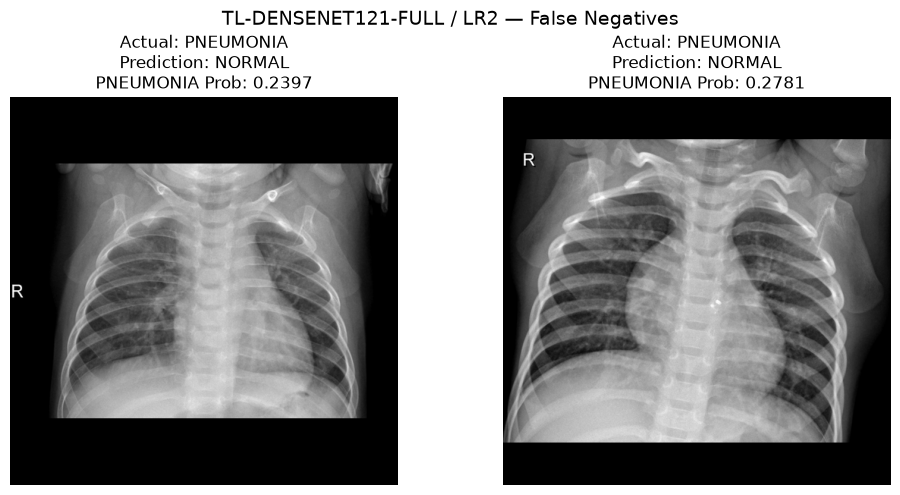

In [ ]:
# ============================================================
# False Negative Image Check
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

N_SAMPLES = len(fn_df)

fig, axes = plt.subplots(
    1,
    N_SAMPLES,
    figsize=(5 * N_SAMPLES, 5),
)

if N_SAMPLES == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, fn_df.iterrows()):
    image_path = (
        Path(DATASET_TEST_DIR)
        / row["Folder"]
        / row["File"]
    )

    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"Actual: PNEUMONIA\n"
        f"Prediction: NORMAL\n"
        f"PNEUMONIA Prob: {row['probability']:.4f}"
    )
    ax.axis("off")

plt.suptitle(
    f"{ERROR_EXPERIMENT} / {ERROR_RUN} — False Negatives",
    fontsize=14,
)

plt.tight_layout()
plt.show()

D:\DEV\AI\projects\chest-xray-pneumonia\experiments\TL-DENSENET121-FULL\LR2\model.pth
densenet121


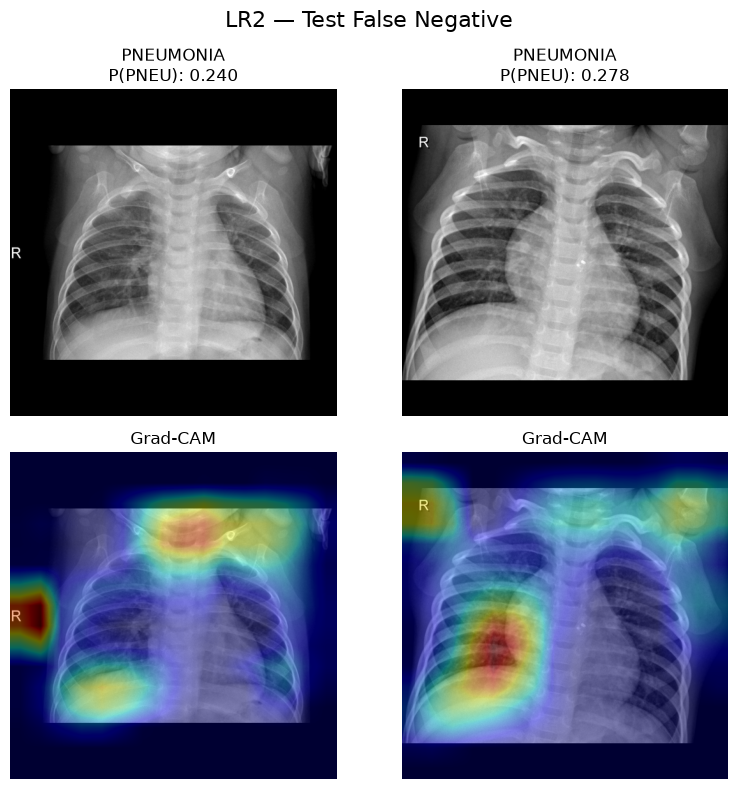

In [ ]:
# ============================================================
# False Negative Grad-CAM
# ============================================================

from cxp import cxp_gradcam

GRADCAM_EXPERIMENT = "TL-DENSENET121-FULL"
GRADCAM_RUN = "LR2"
N_SAMPLES = len(fn_df)

run_info = final_candidate_runs[
    (final_candidate_runs["experiment"] == GRADCAM_EXPERIMENT)
    & (final_candidate_runs["run"] == GRADCAM_RUN)
].iloc[0]

model = load_experiment_model(run_info)

target_layer = cxp_gradcam.get_gradcam_target_layer(
    model=model,
    model_name=run_info["model"],
)

gradcam = cxp_gradcam.GradCAM(
    model=model,
    target_layer=target_layer,
)

eval_transform = create_transform(
    image_size=IMAGE_SIZE,
    mean=NORMALIZATION["mean"],
    std=NORMALIZATION["std"],
)

fn_gradcam = fn_df.copy()

fn_gradcam["y_true"] = fn_gradcam["actual"]
fn_gradcam["y_pred"] = fn_gradcam["prediction"]
fn_gradcam["y_prob"] = fn_gradcam["probability"]

cxp_gradcam.plot_gradcam_samples(
    dataframe=fn_gradcam,
    gradcam=gradcam,
    transform=eval_transform,
    image_dir=DATASET_TEST_DIR,
    n_samples=N_SAMPLES,
    title_prefix=f"{GRADCAM_RUN} — Test False Negative",
    device=DEVICE,
)

cxp_gradcam.cleanup_gradcam(
    gradcam=gradcam,
    model=model,
)

Test Error Analysis

1. False Positive
   → 정상 영상을 PNEUMONIA로 예측
   → 어깨/팔, 하단 문자·노이즈 영역에 activation 관찰

2. False Negative
   → PNEUMONIA를 NORMAL로 예측
   → 하단 문자·노이즈, 어깨뼈 영역에 activation 관찰

3. 공통 관찰
   → 일부 오류 사례에서 폐 외부 영역에 높은 activation
   → 모델이 비진단적 영상 특성을 활용했을 가능성
   → Shortcut learning / spurious correlation 가능성

4. 추가 검증 과제
   → Train 데이터에서 해당 패턴의 분포 확인
   → Annotation masking
   → Lung ROI / segmentation

In [68]:

comparison_columns = [
    "experiment",
    "run",
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "roc_auc",
    "tn",
    "fp",
    "fn",
    "tp",
]

display(
    test_results_df[comparison_columns]
    .sort_values("experiment")
    .reset_index(drop=True)
)

,experiment,run,accuracy,precision,recall,specificity,f1,roc_auc,tn,fp,fn,tp
0,TL-DENSENET121-FULL,LR2,0.812500,0.771372,0.994872,0.508547,0.868981,0.944554,119,115,2,388
1,TL-RESNET50-FULL,LR2-EPOCH20,0.759615,0.722222,1.000000,0.358974,0.838710,0.926633,84,150,0,390


In [ ]:
# ============================================================
# Validation vs Test Comparison
# ============================================================

validation_columns = [
    "experiment",
    "run",
    "best_validation_accuracy",
]

final_validation = (
    experiment_summary[
        experiment_summary.set_index(["experiment", "run"]).index.isin(
            final_candidate_runs.set_index(["experiment", "run"]).index
        )
    ][validation_columns]
    .copy()
)

final_validation

,experiment,run,best_validation_accuracy
1,TL-DENSENET121-FULL,LR2,0.996169
7,TL-RESNET50-FULL,LR2-EPOCH20,0.993295


In [70]:
validation_test_comparison = final_validation.merge(
    test_results_df[
        ["experiment", "run", "accuracy"]
    ],
    on=["experiment", "run"],
    how="inner",
)

validation_test_comparison["accuracy_gap"] = (
    validation_test_comparison["accuracy"]
    - validation_test_comparison["best_validation_accuracy"]
)

display(
    validation_test_comparison
    .sort_values("experiment")
    .reset_index(drop=True)
)

,experiment,run,best_validation_accuracy,accuracy,accuracy_gap
0,TL-DENSENET121-FULL,LR2,0.996169,0.812500,-0.183669
1,TL-RESNET50-FULL,LR2-EPOCH20,0.993295,0.759615,-0.233680


In [ ]:
# ============================================================
#  Final Model Comparison
# ============================================================

validation_compare_columns = [
    "experiment",
    "run",
    "model",
    "best_validation_accuracy",
]

validation_compare = (
    experiment_summary[
        validation_compare_columns
    ]
    .copy()
)

display(
    validation_compare
    .sort_values(["model", "experiment", "run"])
    .reset_index(drop=True)
)

,experiment,run,model,best_validation_accuracy
0,TL-DENSENET121-FULL,LR1,DenseNet,0.992337
1,TL-DENSENET121-FULL,LR2,DenseNet,0.996169
2,TL-DENSENET121-LR,LR1,DenseNet,0.969349
3,TL-DENSENET121-LR,LR2,DenseNet,0.944444
4,TL-DENSENET121-PARTIAL,LR1,DenseNet,0.995211
5,TL-DENSENET121-PARTIAL,LR2,DenseNet,0.990421
6,TL-RESNET50-FULL,LR2,ResNet,0.993295
7,TL-RESNET50-FULL,LR2-EPOCH20,ResNet,0.993295
8,TL-RESNET50-LR,LR1,ResNet,0.954023
9,TL-RESNET50-LR,LR2,ResNet,0.918582


## 9. Conclusion

### 9-1. Experiment Summary

이번 실험에서는 Chest X-ray Pneumonia 분류를 대상으로 ResNet50과 DenseNet121의
Transfer Learning 성능을 비교하고, Frozen / Partial / Full Fine-tuning 단계에 따른
변화를 확인하였다.

Fine-tuning을 적용하면서 Validation 성능은 크게 향상되었으며,
최종 후보 모델의 Validation Accuracy는 약 99% 수준까지 도달하였다.

그러나 독립적인 Test 데이터에서는 Validation 성능이 그대로 유지되지 않았으며,
다음과 같은 성능 차이가 확인되었다.

| Model | Validation Accuracy | Test Accuracy | Accuracy Gap |
|---|---:|---:|---:|
| DenseNet121 Full | 99.62% | 81.25% | -18.37%p |
| ResNet50 Full | 99.33% | 75.96% | -23.37%p |

따라서 Validation 성능만으로 모델의 일반화 성능을 판단하기에는 한계가 있음을 확인하였다.

### 9-2. Error Analysis

Test Error Analysis에서는 False Positive와 False Negative 사례를 확인하고
Grad-CAM을 이용하여 모델의 주요 activation 영역을 분석하였다.

일부 오류 사례에서 폐 영역뿐만 아니라 어깨·팔 영역과 이미지 하단의
문자 및 촬영 관련 정보 영역에 높은 activation이 반복적으로 관찰되었다.

이는 모델이 폐렴과 직접적인 관련이 없는 영상 특성을 분류 과정에서
활용했을 가능성을 보여준다.

다만 Grad-CAM만으로 해당 영역이 실제 오분류의 직접적인 원인이라고
단정할 수는 없으며, 데이터 분포와 비진단적 특징의 분포를 추가로 확인할 필요가 있다.

### 9-3. Next Steps

향후 과제 수행에 필요한 실험은 **전처리 단계가 모델의 일반화 성능에 미치는 영향**을 검증하는 것이다.

Validation에서는 약 99%에서 Test에서는 성능이 75~85% 까지 크게 하락했으며, Error Analysis와 Grad-CAM에서 어깨와 팔, 글자에서 높은 activation이 반복적으로 관찰되었다.

따라서 다음 학습에서는 **모델 구조 자체보다 먼저 전처리 과정에서 비진단적 특징이 모델에 학습될 가능성**을 확인한다.

추가 실험은 다음 순서로 진행한다.

1. **현재 전처리 결과를 기준선변경**

   * 기존 Resize 등의 전처리 결과를 Baseline으로 -> 이미지 Argumentation까지 고려하면 리사이즈처리는 분석전 단계에서 시행하는 것을 원칙으로한다.
   * 기존 전처리 기준과의 차이를 비교하기 위해 이미지를 미리 생성하는 것은 잘못된 학습조건으로 되는걸 앞 실험에서 확인하여 기준을 변경함.

2. **Annotation / Text Masking**

   * 이미지에 포함된 문자, 마커 등의 영역을 제거하거나 Masking
   * Masking 전후 Validation/Test 성능과 Error Analysis 비교
   * 단순히 문자를 읽기 위한 OCR이 목적이 아니라, 모델이 해당 정보를 활용하지 못하도록 하는 것이 목적

3. **Lung ROI / Lung Segmentation**

   * 폐 영역을 중심으로 입력을 제한하는 전처리 실험
   * pretrained Lung Segmentation 모델 등을 활용하여 폐 영역을 추출
   * 전체 이미지 입력과 Lung ROI 입력의 성능 및 Grad-CAM 비교

4. **전처리 실험을 통한 원인 검증**

   * 동일한 모델과 학습 조건을 유지한 상태에서 전처리만 변경
   * 이를 통해 Test 성능 하락이 비진단적 영상 특징 또는 전처리 방식과 관련이 있는지 검증

5. **Error Analysis 재수행**

   * 각 전처리 방식에서 FP/FN을 다시 확인
   * Grad-CAM을 통해 모델의 activation 영역이 실제로 변화하는지 비교

이번 추가 학습의 목적은 단순히 Test Accuracy를 높이는 것이 아니라, **이번 실험에서 발생한 Validation–Test 성능 차이가 어떤 전처리 및 데이터 특성과 관련되어 있는지를 실험적으로 확인하는 것**이다.

이를 통해 전처리를 단순한 이미지 크기 조정이나 정규화 과정으로 보는 것이 아니라, **모델이 어떤 정보를 학습할 수 있도록 허용할 것인가를 결정하는 중요한 설계 단계**로 이해하는 것을 목표로 한다.



